--- First 5 Rows ---
       Country  LifeExpectancy  MeanYearsSchooling  ExpectedYearsSchooling  \
0      Iceland            82.9                13.7                    19.1   
1  Switzerland            83.6                13.5                    17.8   
2       Norway            82.7                12.6                    18.1   
3      Denmark            81.5                12.7                    17.0   
4       Sweden            82.4                12.9                    17.3   

   GNI perCapita    HDI  
0          73200  0.972  
1          70800  0.970  
2          74500  0.970  
3          67500  0.962  
4          66300  0.959  

--- Unique Countries ---
<StringArray>
[    'Iceland', 'Switzerland',      'Norway',     'Denmark',      'Sweden',
   'Hong Kong',     'Finland',     'Germany', 'Netherlands',   'Australia',
       'India',     'Nigeria',      'Brazil',       'Japan',      'Canada']
Length: 15, dtype: str


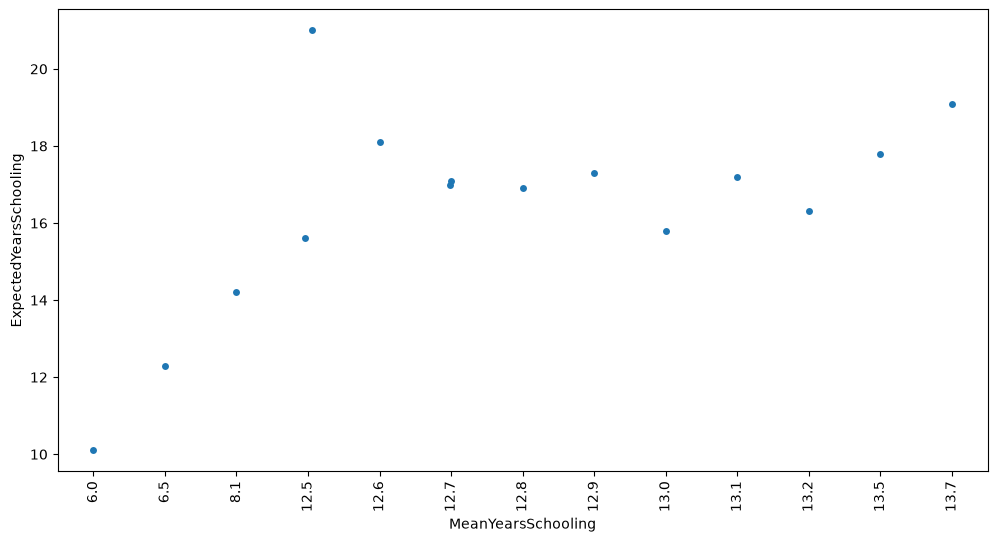

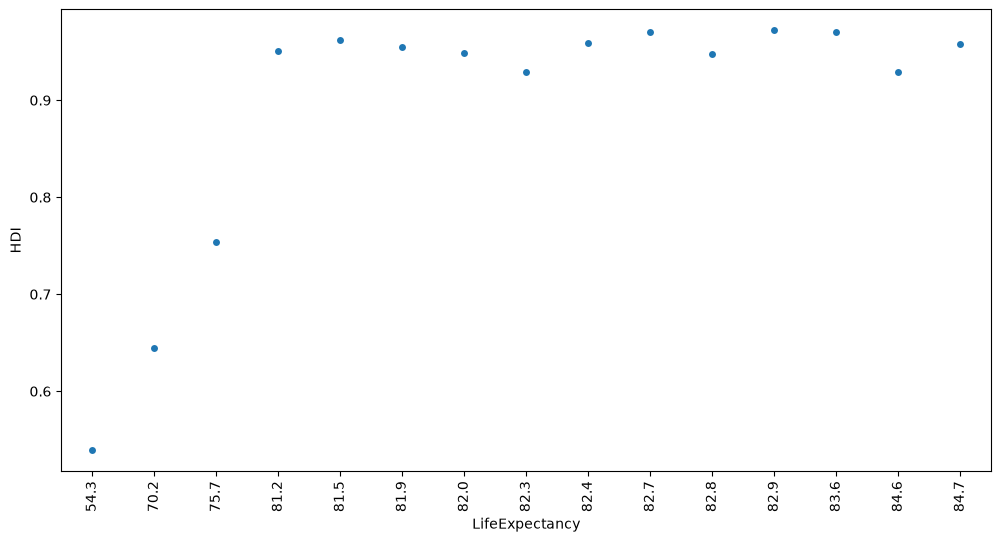

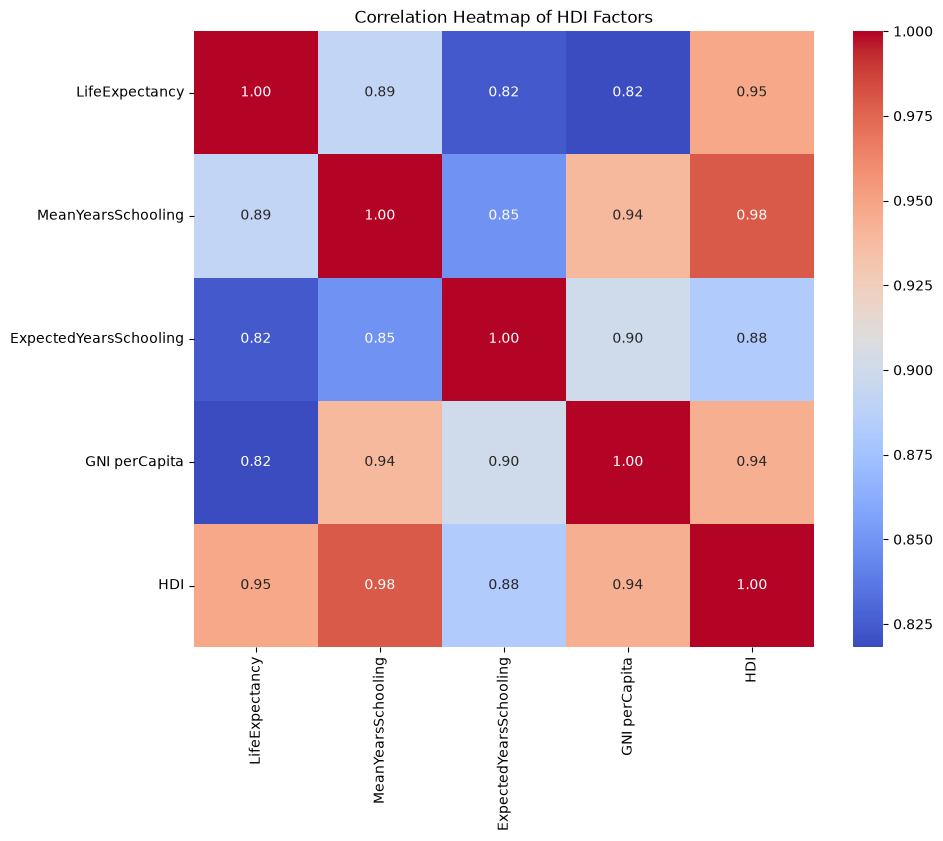

Independent variables (X) columns: ['LifeExpectancy', 'MeanYearsSchooling', 'ExpectedYearsSchooling', 'GNI perCapita']
Shape of X: (15, 4)
Shape of y: (15,)
Null values before filling:
LifeExpectancy            0
MeanYearsSchooling        0
ExpectedYearsSchooling    0
GNI perCapita             0
dtype: int64

Null values after filling:
LifeExpectancy            0
MeanYearsSchooling        0
ExpectedYearsSchooling    0
GNI perCapita             0
dtype: int64


NameError: name 'reg' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. Load the dataset cleanly
Development = pd.read_csv(r"C:\Users\likhi\Downloads\HDI.csv")

# 2. Print checks
print("--- First 5 Rows ---")
print(Development.head())

print("\n--- Unique Countries ---")
print(Development["Country"].unique())

# 3. Data Visualization
plt.figure(figsize=(12, 6)) # Makes the plot wider so country names fit better
# Replace 'Exact_X_Name' and 'Exact_Y_Name' with what you see in the printed list!
g = sns.stripplot(x="MeanYearsSchooling", y="ExpectedYearsSchooling", data=Development, jitter=True)
plt.xticks(rotation=90)
plt.show()
# Life Expectancy Visualization
plt.figure(figsize=(12, 6))

g = sns.stripplot(x="LifeExpectancy", y="HDI", data=Development, jitter=True)
plt.xticks(rotation=90)

plt.show()
# 1. Select only the columns that actually contain numbers
# This avoids index errors and ignores text columns like "Country"
numeric_data = Development.select_dtypes(include=['float64', 'int64'])

# 2. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of HDI Factors")
plt.show()
# --- Independent Variables (Features) ---
# We drop 'Country' (text) and 'HDI' (the target we want to predict)
X = Development.drop(columns=['Country', 'HDI'])

# --- Dependent Variable (Target) ---
y = Development['HDI']

# Verify the shapes
print("Independent variables (X) columns:", X.columns.tolist())
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
X.isnull().sum()
# Check for null values before filling
print("Null values before filling:")
print(X.isnull().sum())

# Replacing the null values with the column mean (Notice the capital X!)
X = X.fillna(X.mean())

# Verify that null values are now 0
print("\nNull values after filling:")
print(X.isnull().sum())
#testing with few values
y_pred=reg.predict([[13,72.0,5.2,3341.0,14.4]])
print(y_pred)
y_test
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Create and train the model
reg = LinearRegression()
reg.fit(X_train, y_train)

# 3. Now your testing code will work!
print("--- Making a Sample Prediction ---")
y_pred = reg.predict([[13.0, 72.0, 5.2, 3341.0]]) # Adjust the number of features if needed
print("Predicted HDI:", y_pred)
y_pred=reg.predict(x_test)
print(y_pred)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Re-create and train your model right here
reg = LinearRegression()
reg.fit(X_train, y_train)

# 3. Save the trained model to a file immediately
with open('HDI.pkl', 'wb') as f:
    pickle.dump(reg, f)

print("SUCCESS: Your machine learning model has been saved as 'HDI.pkl'!")

SUCCESS: Your machine learning model has been saved as 'HDI.pkl'!


In [31]:
# importing the necessary dependencies
import numpy as np # used for numerical analysis
import pandas as pd # used for data manipulation
from flask import Flask, render_template, request
import pickle

app = Flask(__name__) # initializing a flask app
model = pickle.load(open('HDI.pkl', 'rb')) # loading the model

@app.route('/') # route to display the home page
def home():
    return render_template('home.html') # rendering the home page

@app.route('/Prediction', methods=['POST', 'GET'])
def prediction():
    return render_template('indexnew.html')

@app.route('/Home', methods=['POST', 'GET'])
def my_home():
    return render_template('home.html')

@app.route('/predict', methods=['POST']) # route to show the predictions in a web UI
def predict():
    # reading the inputs given by the user
    input_features = [float(x) for x in request.form.values()]
    features_value = [np.array(input_features)]
    
    # Note: Ensure these columns exactly match the feature columns your model was trained on!
    features_name = ['LifeExpectancy', 'MeanYearsSchooling', 'ExpectedYearsSchooling'] 
    
    df = pd.DataFrame(features_value, columns=features_name)
    
    # predictions using the loaded model file
    output = model.predict(df)
    
    # Extract prediction value safely depending on shape
    if hasattr(output, "__len__") and len(output.shape) > 1:
        y_pred = round(output[0][0], 2)
    else:
        y_pred = round(output[0], 2)
        
    if y_pred >= 0.3 and y_pred <= 0.4:
        return render_template('resultnew.html', prediction_text='Low HDI: ' + str(y_pred))
    elif y_pred > 0.4 and y_pred <= 0.7:
        return render_template('resultnew.html', prediction_text='Medium HDI: ' + str(y_pred))
    elif y_pred > 0.7 and y_pred <= 0.8:
        return render_template('resultnew.html', prediction_text='High HDI: ' + str(y_pred))
    elif y_pred > 0.8 and y_pred <= 0.94:
        return render_template('resultnew.html', prediction_text='Very High HDI: ' + str(y_pred))
    else:
        return render_template('resultnew.html', prediction_text='The given values do not match the range of values: ' + str(y_pred))

if __name__ == '__main__':
    # running the app
    app.run(debug=True, port=5000)

ModuleNotFoundError: No module named 'flask'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# 1. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)

# 2. Save it directly inside the Flask/templates folder so app.py can see it
# Using a raw string (r"...") ensures Windows paths don't break on backslashes
pickle_path = r"C:\Users\likhi\OneDrive\Desktop\apsche_ai\Flask\templates\HDI.pkl"

with open(pickle_path, 'wb') as f:
    pickle.dump(reg, f)

print("SUCCESS: Model overwritten and saved cleanly at:", pickle_path)

In [15]:
print(Development.columns.tolist())

['Country', 'LifeExpectancy', 'MeanYearsSchooling', 'ExpectedYearsSchooling', 'GNI perCapita', 'HDI']
